In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# AWGN noise addition function based on desired SNR (dB)
# Desired SNR (linear) = Signal_Power / Noise_Power
def add_awgn_noise(signal, snr_db):
    sig_power = np.mean(np.abs(signal)**2)
    snr_linear = 10.0 ** (snr_db / 10.0)
    noise_power = sig_power / snr_linear

    if np.iscomplexobj(signal):
        # Complex circular AWGN (variance split equally into I and Q)
        noise = (np.random.randn(len(signal)) + 1j * np.random.randn(len(signal))) * np.sqrt(noise_power / 2.0)
    else:
        # Real AWGN
        noise = np.random.randn(len(signal)) * np.sqrt(noise_power)

    return signal + noise

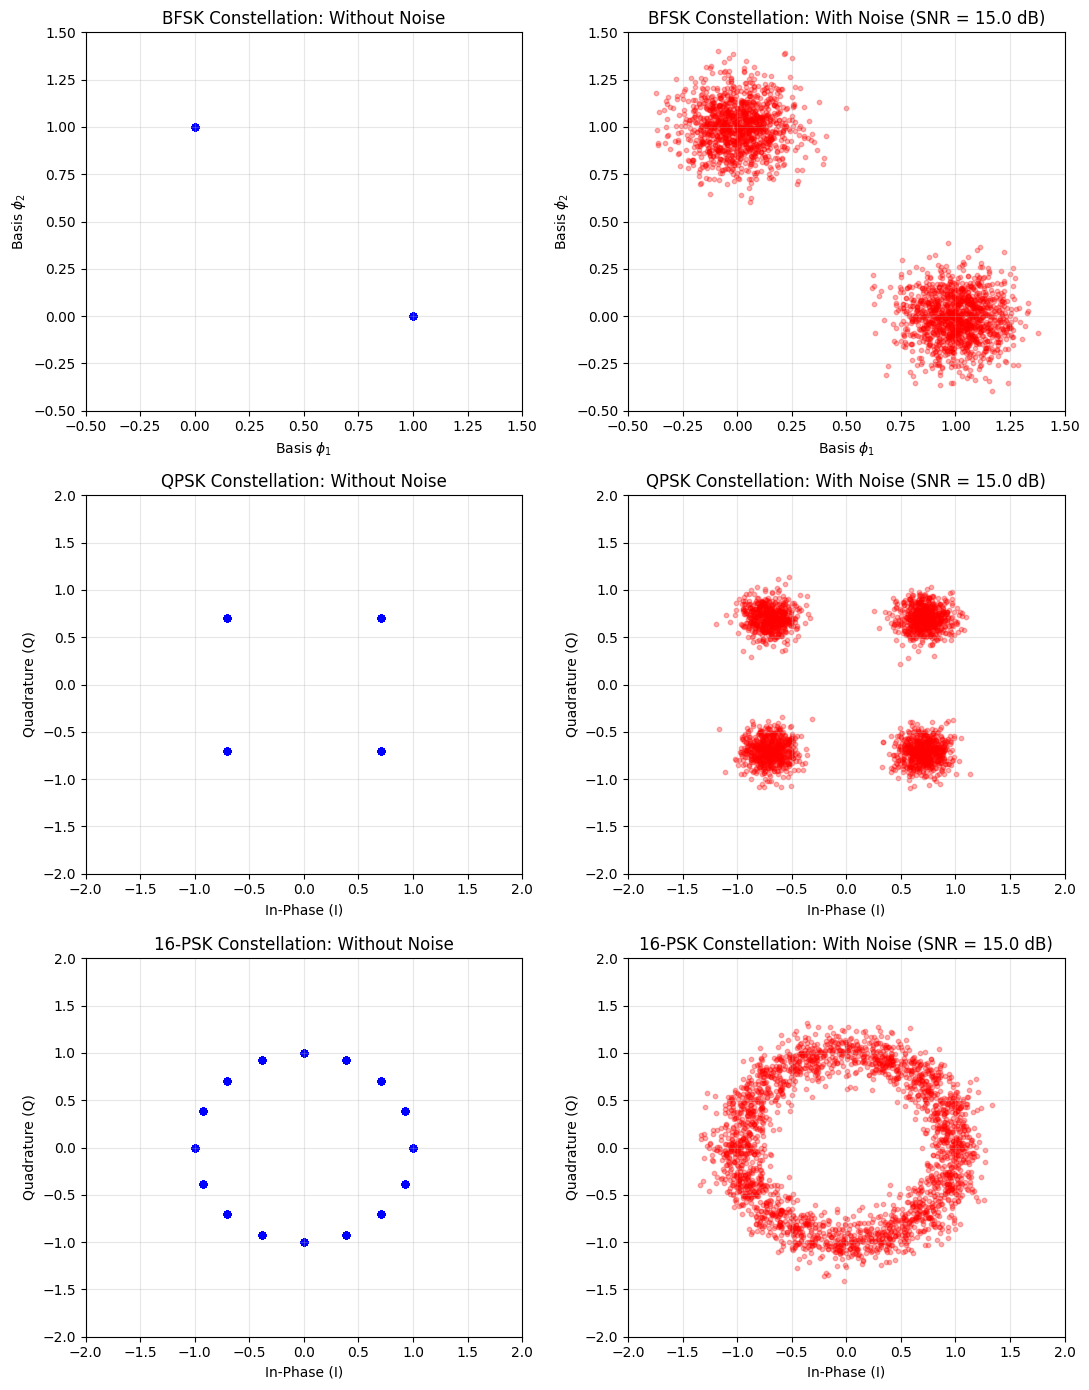

In [2]:
np.random.seed(42)
N = 2500
snr_db = 15.0

# 1. BFSK (Orthogonal 2D Basis Representation)
bits_bfsk = np.random.randint(0, 2, N)
# Basis coords: bit 0 -> (1, 0), bit 1 -> (0, 1)
clean_bfsk = np.zeros((N, 2))
clean_bfsk[bits_bfsk == 0, 0] = 1.0
clean_bfsk[bits_bfsk == 1, 1] = 1.0
noisy_bfsk = np.column_stack([
    add_awgn_noise(clean_bfsk[:, 0], snr_db),
    add_awgn_noise(clean_bfsk[:, 1], snr_db)
])

# 2. QPSK
symbols_qpsk = np.random.randint(0, 4, N)
clean_qpsk = np.exp(1j * (2 * np.pi * symbols_qpsk / 4 + np.pi / 4))
noisy_qpsk = add_awgn_noise(clean_qpsk, snr_db)

# 3. 16-PSK
symbols_16psk = np.random.randint(0, 16, N)
clean_16psk = np.exp(1j * (2 * np.pi * symbols_16psk / 16))
noisy_16psk = add_awgn_noise(clean_16psk, snr_db)

# Plotting Constellations
fig, axes = plt.subplots(3, 2, figsize=(11, 14))

# BFSK Plots
axes[0, 0].scatter(clean_bfsk[:, 0], clean_bfsk[:, 1], color='blue', alpha=0.5, s=20)
axes[0, 0].set_title('BFSK Constellation: Without Noise')
axes[0, 0].set_xlabel(r'Basis $\phi_1$')
axes[0, 0].set_ylabel(r'Basis $\phi_2$')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(-0.5, 1.5); axes[0, 0].set_ylim(-0.5, 1.5)

axes[0, 1].scatter(noisy_bfsk[:, 0], noisy_bfsk[:, 1], color='red', alpha=0.3, s=10)
axes[0, 1].set_title(f'BFSK Constellation: With Noise (SNR = {snr_db} dB)')
axes[0, 1].set_xlabel(r'Basis $\phi_1$')
axes[0, 1].set_ylabel(r'Basis $\phi_2$')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(-0.5, 1.5); axes[0, 1].set_ylim(-0.5, 1.5)

# QPSK Plots
axes[1, 0].scatter(np.real(clean_qpsk), np.imag(clean_qpsk), color='blue', alpha=0.5, s=20)
axes[1, 0].set_title('QPSK Constellation: Without Noise')
axes[1, 0].set_xlabel('In-Phase (I)')
axes[1, 0].set_ylabel('Quadrature (Q)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(-2, 2); axes[1, 0].set_ylim(-2, 2)

axes[1, 1].scatter(np.real(noisy_qpsk), np.imag(noisy_qpsk), color='red', alpha=0.3, s=10)
axes[1, 1].set_title(f'QPSK Constellation: With Noise (SNR = {snr_db} dB)')
axes[1, 1].set_xlabel('In-Phase (I)')
axes[1, 1].set_ylabel('Quadrature (Q)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(-2, 2); axes[1, 1].set_ylim(-2, 2)

# 16-PSK Plots
axes[2, 0].scatter(np.real(clean_16psk), np.imag(clean_16psk), color='blue', alpha=0.5, s=20)
axes[2, 0].set_title('16-PSK Constellation: Without Noise')
axes[2, 0].set_xlabel('In-Phase (I)')
axes[2, 0].set_ylabel('Quadrature (Q)')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(-2, 2); axes[2, 0].set_ylim(-2, 2)

axes[2, 1].scatter(np.real(noisy_16psk), np.imag(noisy_16psk), color='red', alpha=0.3, s=10)
axes[2, 1].set_title(f'16-PSK Constellation: With Noise (SNR = {snr_db} dB)')
axes[2, 1].set_xlabel('In-Phase (I)')
axes[2, 1].set_ylabel('Quadrature (Q)')
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].set_xlim(-2, 2); axes[2, 1].set_ylim(-2, 2)

plt.tight_layout()
plt.show()

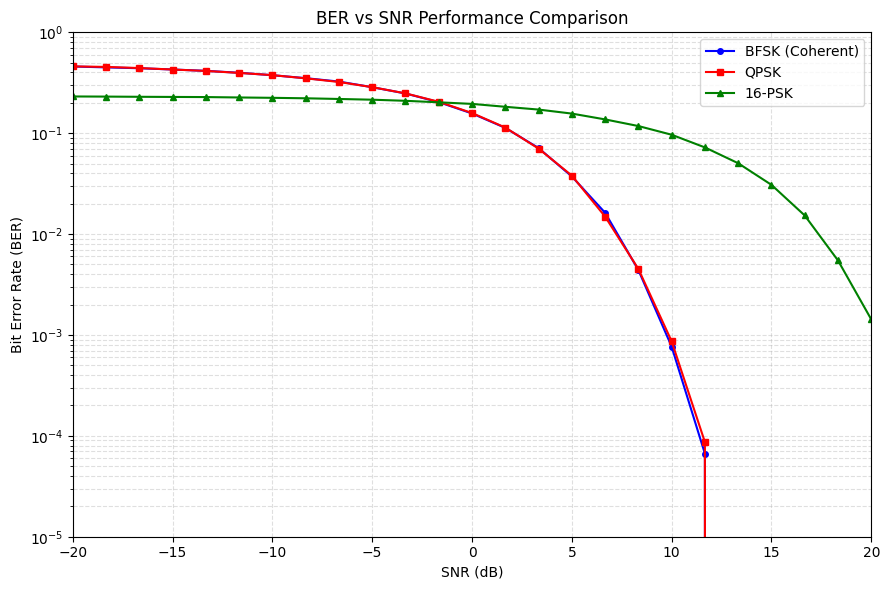

In [3]:
snr_range = np.linspace(-20, 20, 25)
num_bits = 150000

ber_bfsk = []
ber_qpsk = []
ber_16psk = []

for snr in snr_range:
    # 1. BFSK (Coherent detection on orthogonal components)
    bits = np.random.randint(0, 2, num_bits)
    sig_f1 = np.where(bits == 0, 1.0, 0.0)
    sig_f2 = np.where(bits == 1, 1.0, 0.0)

    noisy_f1 = add_awgn_noise(sig_f1, snr)
    noisy_f2 = add_awgn_noise(sig_f2, snr)
    dec_bfsk = np.where(noisy_f2 > noisy_f1, 1, 0)
    ber_bfsk.append(np.mean(bits != dec_bfsk))

    # 2. QPSK (Gray coded 2 bits per symbol)
    b_i = np.random.randint(0, 2, num_bits // 2)
    b_q = np.random.randint(0, 2, num_bits // 2)
    s_i = 2 * b_i - 1
    s_q = 2 * b_q - 1
    qpsk_sym = (s_i + 1j * s_q) / np.sqrt(2)

    noisy_q = add_awgn_noise(qpsk_sym, snr)
    dec_bi = np.where(np.real(noisy_q) > 0, 1, 0)
    dec_bq = np.where(np.imag(noisy_q) > 0, 1, 0)
    ber_qpsk.append((np.mean(b_i != dec_bi) + np.mean(b_q != dec_bq)) / 2.0)

    # 3. 16-PSK
    k = 4
    n_syms = num_bits // k
    sym_idx = np.random.randint(0, 16, n_syms)
    psk_syms = np.exp(1j * (2 * np.pi * sym_idx / 16))
    noisy_psk = add_awgn_noise(psk_syms, snr)

    rx_phases = np.mod(np.angle(noisy_psk), 2 * np.pi)
    dec_syms = np.round(rx_phases / (2 * np.pi / 16)).astype(int) % 16
    ser_16 = np.mean(sym_idx != dec_syms)
    ber_16psk.append(ser_16 / k)  # Approximate BER from SER

# Plot BER vs SNR Curves
plt.figure(figsize=(9, 6))
plt.semilogy(snr_range, ber_bfsk, 'b-o', markersize=4, label='BFSK (Coherent)')
plt.semilogy(snr_range, ber_qpsk, 'r-s', markersize=4, label='QPSK')
plt.semilogy(snr_range, ber_16psk, 'g-^', markersize=4, label='16-PSK')

plt.title('BER vs SNR Performance Comparison')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.ylim(1e-5, 1.0)
plt.xlim(-20, 20)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

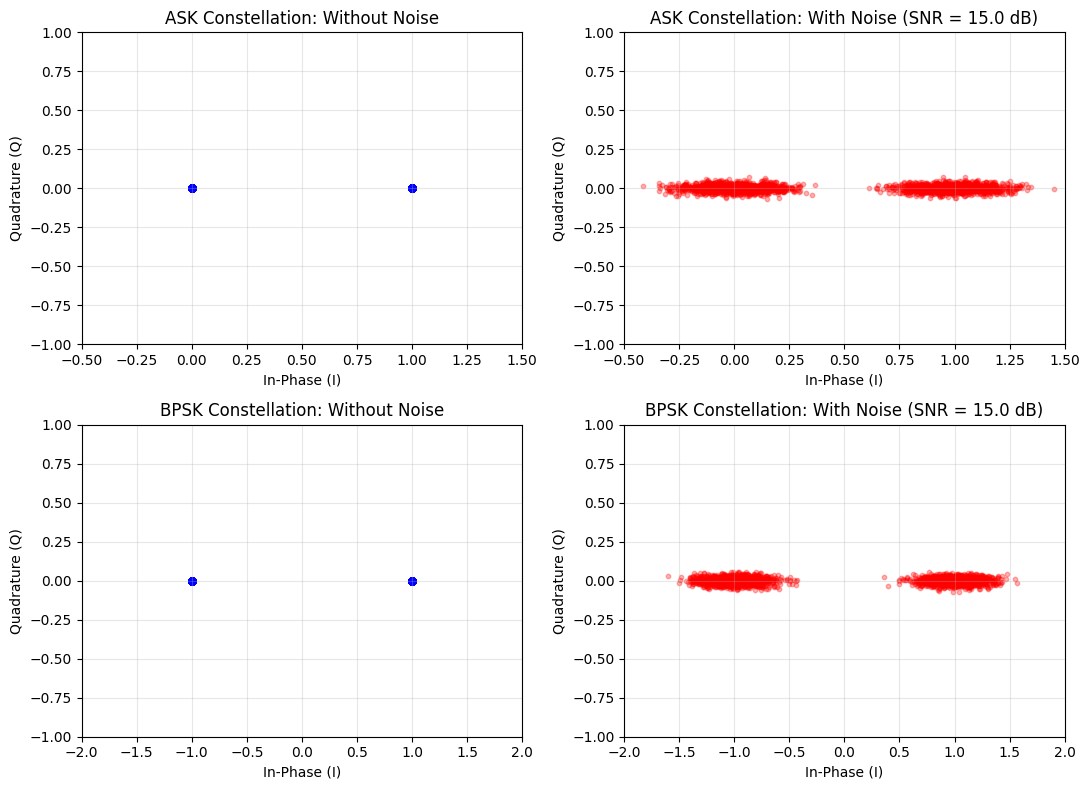

In [4]:
np.random.seed(10)
N = 2500
snr_db = 15.0

# 1. Binary ASK (OOK: 0 and 1)
bits_ask = np.random.randint(0, 2, N)
clean_ask = bits_ask.astype(float)
noisy_ask = add_awgn_noise(clean_ask, snr_db)

# 2. BPSK (-1 and +1)
bits_bpsk = np.random.randint(0, 2, N)
clean_bpsk = 2 * bits_bpsk.astype(float) - 1.0
noisy_bpsk = add_awgn_noise(clean_bpsk, snr_db)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# ASK Plots
axes[0, 0].scatter(clean_ask, np.zeros(N), color='blue', alpha=0.5, s=25)
axes[0, 0].set_title('ASK Constellation: Without Noise')
axes[0, 0].set_xlabel('In-Phase (I)')
axes[0, 0].set_ylabel('Quadrature (Q)')
axes[0, 0].set_ylim(-1, 1); axes[0, 0].set_xlim(-0.5, 1.5)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(noisy_ask, np.zeros(N) + np.random.normal(0, 0.02, N), color='red', alpha=0.3, s=10)
axes[0, 1].set_title(f'ASK Constellation: With Noise (SNR = {snr_db} dB)')
axes[0, 1].set_xlabel('In-Phase (I)')
axes[0, 1].set_ylabel('Quadrature (Q)')
axes[0, 1].set_ylim(-1, 1); axes[0, 1].set_xlim(-0.5, 1.5)
axes[0, 1].grid(True, alpha=0.3)

# BPSK Plots
axes[1, 0].scatter(clean_bpsk, np.zeros(N), color='blue', alpha=0.5, s=25)
axes[1, 0].set_title('BPSK Constellation: Without Noise')
axes[1, 0].set_xlabel('In-Phase (I)')
axes[1, 0].set_ylabel('Quadrature (Q)')
axes[1, 0].set_ylim(-1, 1); axes[1, 0].set_xlim(-2, 2)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(noisy_bpsk, np.zeros(N) + np.random.normal(0, 0.02, N), color='red', alpha=0.3, s=10)
axes[1, 1].set_title(f'BPSK Constellation: With Noise (SNR = {snr_db} dB)')
axes[1, 1].set_xlabel('In-Phase (I)')
axes[1, 1].set_ylabel('Quadrature (Q)')
axes[1, 1].set_ylim(-1, 1); axes[1, 1].set_xlim(-2, 2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

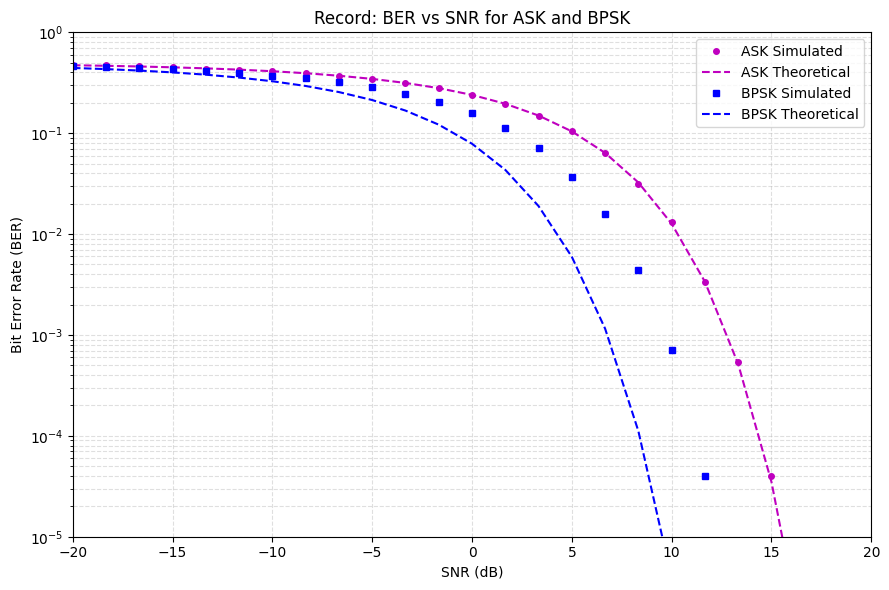

In [5]:
snr_range = np.linspace(-20, 20, 25)
num_bits = 150000

ber_ask = []
ber_bpsk = []

for snr in snr_range:
    bits = np.random.randint(0, 2, num_bits)

    # 1. ASK (OOK: Threshold at 0.5)
    ask_tx = bits.astype(float)
    noisy_ask = add_awgn_noise(ask_tx, snr)
    dec_ask = np.where(noisy_ask > 0.5, 1, 0)
    ber_ask.append(np.mean(bits != dec_ask))

    # 2. BPSK (Antipodal: Threshold at 0.0)
    bpsk_tx = 2 * bits.astype(float) - 1.0
    noisy_bpsk = add_awgn_noise(bpsk_tx, snr)
    dec_bpsk = np.where(noisy_bpsk > 0.0, 1, 0)
    ber_bpsk.append(np.mean(bits != dec_bpsk))

# Theoretical curves for verification
snr_lin = 10.0 ** (snr_range / 10.0)
theory_bpsk = 0.5 * erfc(np.sqrt(snr_lin))
theory_ask = 0.5 * erfc(np.sqrt(snr_lin / 4.0))

plt.figure(figsize=(9, 6))
plt.semilogy(snr_range, ber_ask, 'mo', markersize=4, label='ASK Simulated')
plt.semilogy(snr_range, theory_ask, 'm--', label='ASK Theoretical')
plt.semilogy(snr_range, ber_bpsk, 'bs', markersize=4, label='BPSK Simulated')
plt.semilogy(snr_range, theory_bpsk, 'b--', label='BPSK Theoretical')

plt.title('Record: BER vs SNR for ASK and BPSK')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.ylim(1e-5, 1.0)
plt.xlim(-20, 20)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()